### AIRPORT SIMULATION ###

In [ ]:
#importing libraries and use of main classes adapted from CS166 class content
import heapq
import scipy.stats as sts
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

#for the plot styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

class Event:
    '''
    Store the properties of one event in the Schedule class defined below. Each
    event has a time at which it needs to run, a function to call when running
    the event, along with the arguments and keyword arguments to pass to that
    function.
    '''
    def __init__(self, timestamp, function, *args, **kwargs):
        self.timestamp = timestamp
        self.function = function
        self.args = args
        self.kwargs = kwargs

    def __lt__(self, other):
        '''
        This overloads the less-than operator in Python. We need it so the
        priority queue knows how to compare two events. We want events with
        earlier (smaller) times to go first.
        '''
        return self.timestamp < other.timestamp

    def run(self, schedule):
        '''
        Run an event by calling the function with its arguments and keyword
        arguments. The first argument to any event function is always the
        schedule in which events are being tracked. The schedule object can be
        used to add new events to the priority queue.
        '''
        self.function(schedule, *self.args, **self.kwargs)


class Schedule:
    '''
    Implement an event schedule using a priority queue. You can add events and
    run the next event.

    The 'now' attribute contains the time at which the last event was run.
    '''

    def __init__(self):
        self.now = 0  # Keep track of the current simulation time
        self.priority_queue = []  # The priority queue of events to run

    def add_event_at(self, timestamp, function, *args, **kwargs):
        # Add an event to the schedule at a particular point in time.
        heapq.heappush(
            self.priority_queue,
            Event(timestamp, function, *args, **kwargs))

    def add_event_after(self, interval, function, *args, **kwargs):
        # Add an event to the schedule after a specified time interval.
        self.add_event_at(self.now + interval, function, *args, **kwargs)

    def next_event_time(self):
        return self.priority_queue[0].timestamp

    def run_next_event(self):
        # Get the next event from the priority queue and run it.
        event = heapq.heappop(self.priority_queue)
        self.now = event.timestamp
        event.run(self)

    def __repr__(self):
        return (
            f'Schedule() at time {self.now}min ' +
            f'with {len(self.priority_queue)} events in the queue')

    def print_events(self):
        print(repr(self))
        for event in sorted(self.priority_queue):
            print(f'  ⏱ {event.timestamp}min: {event.function.__name__}')

## M/G/k queue

In [ ]:
import scipy.stats as sts

class Traveler:
  '''
  to track individual arrival times because assignment asks to measure "Average traveler waiting time"
  '''
  def __init__(self, arrival_time, traveler_id):
        self.arrival_time = arrival_time
        self.id = traveler_id
        self.service_time = 0
        self.departure_time = 0

class Queues:
  """
  stores and manages each one of the lines individually by making them an M/G/1 (one line and one server)

  """
  def __init__(self, queue_id, service_distribution):
        self.queue_id = queue_id
        # Store the service-time distribution for an M/G/1 queue
        self.service_distribution = service_distribution

        #list for travelers waiting people in the queue
        self.queue = []
        self.people_being_served = 0 #maybe change it to a list??]

        #statistics
        #list of waiting times from travelers
        self.waiting_times = []
        self.queue_lenghts = []

        #for average time
        self.last_update_time = 0
        self.area_under_queue_curve = 0

  #create a less than method to compare lenghts of queues slef.len(people inqueue +people_incounter ) <other(people in queue people in the qcounter)

  def update_info(self, current_time):
    '''
    Updates the time-dependent information for the queue.
    '''
    #area under the curve from last update
    time_delta = current_time - self.last_update_time
    current_length = len(self.queue)
    #+ self.people_being_served
    self.area_under_queue_curve += current_length * time_delta
    self.last_update_time = current_time

    #log the data point
    self.queue_lenghts.append((current_time, current_length))

  def add_customer(self, schedule, traveler):
        #update info
        self.update_info(schedule.now)

        #add tarveler object/instance to the created list
        self.queue.append(traveler)

        #check if the server is free
        if self.people_being_served < 1:
            # This customer can be served immediately
            schedule.add_event_after(0, self.start_serving_customer)

  def start_serving_customer(self, schedule):
        self.update_info(schedule.now)

        # Move the customer from the queue to a server
        if len(self.queue) > 0:
            traveler = self.queue.pop(0)
            self.people_being_served += 1

            # Calculate Wait Time: (Current Time - Arrival Time)
            wait_time = schedule.now - traveler.arrival_time
            self.waiting_times.append(wait_time)


            service_time = self.service_distribution.rvs()
            # Schedule when the server will be done
            schedule.add_event_after(
                service_time,
                self.finish_serving_customer)

  def finish_serving_customer(self, schedule):
        self.update_info(schedule.now)

        # Remove the customer from the server
        self.people_being_served -= 1
        if len(self.queue) > 0 :
            # There are more people in the queue so serve the next customer
            schedule.add_event_after(0, self.start_serving_customer)


class Airport:
  """
  Manages the arrival of travelers and distributes them to the shortest queue
  """
  def __init__(self, num_queues, arrival_distribution, service_distribution):
        #list of queues
        self.queues = []
        for i in range(num_queues):
            self.queues.append(Queues(i, service_distribution))

        #arrival distribution information
        self.arrival_distribution = arrival_distribution
        self.total_travelers = 0


  def add_customer(self, schedule):
        #create traveler
        self.total_travelers += 1
        new_traveler = Traveler(schedule.now, self.total_travelers)

        #need to add customer to the shortest queue using greedy algorithm
        shortest_queue = min(self.queues, key=lambda q:len(q.queue) + q.people_being_served) #added to check for queue + people being served for the shortest queue
        shortest_queue.add_customer(schedule, new_traveler)

        # Schedule when to add another customer
        schedule.add_event_after(
            self.arrival_distribution.rvs(),
            self.add_customer)

  def open_airport(self, schedule): #used to be run needs to update
        # Schedule when the first customer arrives
        schedule.add_event_after(
            self.arrival_distribution.rvs(),
            self.add_customer)

def run_simulation(arrival_distribution, service_distribution, num_queues, run_until):
  #need to set up the paramenters here
    schedule = Schedule()

    airport = Airport(num_queues, arrival_distribution, service_distribution)
    airport.open_airport(schedule)
    while schedule.next_event_time() is not None and schedule.next_event_time() < run_until:
        schedule.run_next_event()

    # After the last event, we must update each queue
    # up to run_until to close the area-under-curve
    for q in airport.queues:
        q.update_info(run_until)
    #schedule.now = run_until
    return airport, schedule

## Verifications

In [ ]:
# Verification tests

def run_verification_tests():
    #function to help run multiple trials and calculate the avergae of them
    def run_trials(arrival_dist, service_dist, num_queues, duration):
        results = []
        TRIALS = 1000
        print("Running")

        #loading bar
        for _ in tqdm(range(TRIALS)):
            airport, schedule = run_simulation(arrival_dist, service_dist, num_queues, duration)       # 2. SNAPSHOT: Collect data ONLY at the very end
            # Collect data at the end by counting how many people are standing there right now.
            current_lengths = []
            for q in airport.queues:
                # Just the length of the list at the finish line
                current_lengths.append(len(q.queue))

            # average queue length across the queues for this specific instant
            results.append(np.mean(current_lengths))

        # average of the 1000 snapshots
        return np.mean(results)

    #test 1
    print("Test 1: Uniform Service with 6 queues")
    arrival_dist_1 = sts.expon(scale=1/10)
    service_dist_1 = sts.uniform(loc=0, scale=1)
    num_queues_1 = 6
    duration_1 = 100

    result_1 = run_trials(arrival_dist_1, service_dist_1, num_queues_1, duration_1)

    print(f" Result: {result_1}")

    #checking if it is Mean queue length should be 0.463 ± 0.025 (per queue)
    if 0.438 <= result_1 <= 0.488:
        print("Passed")
    else:
        print("Failed")

    #test 2
    print("Test 2: Truncated Normal with 14 Queues")
    arrival_dist_2 = sts.expon(scale=1/10)
    service_dist_2 = sts.truncnorm(-1, np.inf, loc=1, scale=1)
    num_queues_2 = 14
    duration_2 = 200
    result_2 = run_trials(arrival_dist_2, service_dist_2, num_queues_2, duration_2)
    print(f" Result: {result_2}")


    #checking if it is Mean queue length should be 0.566 ± 0.025 (per queue)
    if 0.541 <= result_2 <= 0.591:
        print("Passed")
    else:
        print("Failed")

run_verification_tests()

Test 1: Uniform Service with 6 queues
Running


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:25<00:00, 11.72it/s]


 Result: 0.4766666666666666
Passed
Test 2: Truncated Normal with 14 Queues
Running


100%|██████████| 1000/1000 [05:17<00:00,  3.15it/s]

 Result: 0.5732142857142857
Passed


In [ ]:
#verification of basic model (theoretical Comparison)

def calculate_theoretical_Lq(k, lam, mu, sigma):
    # We treat verification as single M/G/1 with scaled arrival
    lam_per_queue = lam / k
    rho = lam_per_queue * mu
    if rho >= 1: return float('inf') 
    var = sigma**2
    return ((rho**2 + (lam_per_queue)**2 * var) / (2 * (1 - rho)))

def verify_basic_model():
    print("VERIFICATION: Theory vs Simulation (M/G/1 Equivalent)")
    print("running long simulations to minimize warm-up bias")
    
    lam = 10
    
    # uniform distribution
    k1 = 6
    mu1 = 0.5
    sigma1 = np.sqrt(1/12)
    
    theory_1 = calculate_theoretical_Lq(k1, lam, mu1, sigma1)
    
    # Simulation: 1 queue, scaled arrival
    lam_1_scaled = lam / k1
    sim_res_1 = []
    
    # Running 30 trials for stability
    for _ in range(30):
        # num_queues=1 to match M/G/1 math
        airport, _ = run_simulation(sts.expon(scale=1/lam_1_scaled), sts.uniform(loc=0, scale=1), 1, 20000)
        sim_res_1.append(np.mean([q.area_under_queue_curve/20000 for q in airport.queues]))
    
    sim_val_1 = np.mean(sim_res_1)
    print(f"CASE 1 (Uniform): Theory {theory_1:.3f} | Sim {sim_val_1:.3f} -> {'PASS' if abs(theory_1 - sim_val_1) < 0.15 else 'FAIL'}")

    #case 2: truncated normal
    k2 = 14
    mu2 = 1.0
    sigma2 = 1.0
    
    a, b = (0 - mu2)/sigma2, np.inf
    m_s, v_s = sts.truncnorm.stats(a, b, loc=mu2, scale=sigma2, moments='mv')
    theory_2 = calculate_theoretical_Lq(k2, lam, m_s, np.sqrt(v_s))
    
    lam_2_scaled = lam / k2
    sim_res_2 = []
    
    for _ in range(30):
        airport, _ = run_simulation(sts.expon(scale=1/lam_2_scaled), sts.truncnorm(a, b, loc=mu2, scale=sigma2), 1, 20000)
        sim_res_2.append(np.mean([q.area_under_queue_curve/20000 for q in airport.queues]))
        
    sim_val_2 = np.mean(sim_res_2)
    
    # Increased tolerance slightly because TruncNorm is stochastic
    print(f"CASE 2 (Normal):  Theory {theory_2:.3f} | Sim {sim_val_2:.3f} -> {'PASS' if abs(theory_2 - sim_val_2) < 0.3 else 'FAIL'}")
    print("-" * 60)

verify_basic_model()

🔬 VERIFICATION: Theory vs Simulation (M/G/1 Equivalent)
   Note: Running long simulations (20,000 mins) to minimize warm-up bias.
------------------------------------------------------------
CASE 1 (Uniform): Theory 2.778 | Sim 2.773 -> ✅ PASS
CASE 2 (Normal):  Theory 7.269 | Sim 7.006 -> ✅ PASS
------------------------------------------------------------


Checking Random Distributions


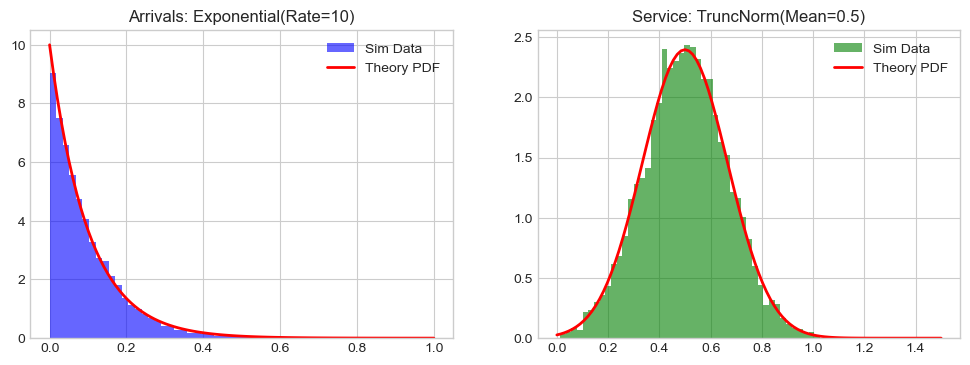

In [5]:
def plot_distribution_check():
    print("Checking Random Distributions")
    # Check Arrivals (Exponential)
    data_arrival = sts.expon(scale=1/10).rvs(size=10000)
    x = np.linspace(0, 1, 100)
    pdf = sts.expon(scale=1/10).pdf(x)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(data_arrival, bins=50, density=True, alpha=0.6, color='blue', label='Sim Data')
    plt.plot(x, pdf, 'r-', lw=2, label='Theory PDF')
    plt.title('Arrivals: Exponential(Rate=10)')
    plt.legend()

    # Check Service (Truncated Normal)
    mu, sigma = 0.5, 1/6
    a, b = (0 - mu) / sigma, np.inf
    data_service = sts.truncnorm(a, b, loc=mu, scale=sigma).rvs(size=10000)
    x2 = np.linspace(0, 1.5, 100)
    pdf2 = sts.truncnorm(a, b, loc=mu, scale=sigma).pdf(x2)

    plt.subplot(1, 2, 2)
    plt.hist(data_service, bins=50, density=True, alpha=0.6, color='green', label='Sim Data')
    plt.plot(x2, pdf2, 'r-', lw=2, label='Theory PDF')
    plt.title('Service: TruncNorm(Mean=0.5)')
    plt.legend()
    plt.show()

plot_distribution_check()

## EXTENDED MODEL

In [ ]:
#EXTENDED MODEL

class QueuesExtended(Queues):
    def __init__(self, queue_id, service_distribution, airport):
        # 1. Correctly call the 2-argument init from Cell 2
        super().__init__(queue_id, service_distribution)
        # 2. Add Airport manually
        self.airport = airport 

    # Override start to intercept service completion
    def start_serving_customer(self, schedule):
        self.update_info(schedule.now)
        if len(self.queue) > 0:
            traveler = self.queue.pop(0)
            self.people_being_served += 1
            
            traveler.service_start_time = schedule.now
            wait_time = schedule.now - traveler.arrival_time
            self.waiting_times.append(wait_time)
            
            service_time = self.service_distribution.rvs()
            # Call EXTENDED finish logic
            schedule.add_event_after(service_time, self.finish_extended_service, traveler)

    def finish_extended_service(self, schedule, traveler):
        self.update_info(schedule.now)
        # Check Secondary Screening
        if self.airport.check_prob > 0 and np.random.random() < self.airport.check_prob:
            self.airport.request_senior_officer(schedule, self, traveler)
        else:
            # Clear: Call basic finish (which decrements people_being_served)
            self.finish_serving_customer(schedule)

    def complete_departure(self, schedule, traveler):
        # Unblock lane
        self.finish_serving_customer(schedule)

class AirportExtended:
    def __init__(self, num_queues, arrival_dist, service_dist, senior_service_dist, check_prob):
        self.queues = [QueuesExtended(i, service_dist, self) for i in range(num_queues)]
        self.arrival_distribution = arrival_dist
        self.senior_service_dist = senior_service_dist
        self.check_prob = check_prob
        self.senior_officer_busy = False
        self.senior_queue = []
        self.total_travelers = 0

    def add_customer(self, schedule):
        self.total_travelers += 1
        new_traveler = Traveler(schedule.now, self.total_travelers)
        shortest_queue = min(self.queues, key=lambda q: len(q.queue) + q.people_being_served)
        shortest_queue.add_customer(schedule, new_traveler)
        schedule.add_event_after(self.arrival_distribution.rvs(), self.add_customer)

    def open_airport(self, schedule):
        schedule.add_event_after(self.arrival_distribution.rvs(), self.add_customer)

    def request_senior_officer(self, schedule, queue_obj, traveler):
        if not self.senior_officer_busy:
            self.senior_officer_busy = True
            self.start_senior_service(schedule, queue_obj, traveler)
        else:
            self.senior_queue.append((queue_obj, traveler))

    def start_senior_service(self, schedule, queue_obj, traveler):
        duration = self.senior_service_dist.rvs()
        schedule.add_event_after(duration, self.finish_senior_service, queue_obj, traveler)

    def finish_senior_service(self, schedule, queue_obj, traveler):
        queue_obj.complete_departure(schedule, traveler)
        if self.senior_queue:
            next_q, next_t = self.senior_queue.pop(0)
            self.start_senior_service(schedule, next_q, next_t)
        else:
            self.senior_officer_busy = False

def run_extended_simulation(arrival_dist, service_dist, num_queues, run_until, senior_dist, check_prob):
    schedule = Schedule()
    airport = AirportExtended(num_queues, arrival_dist, service_dist, senior_dist, check_prob)
    airport.open_airport(schedule)
    while schedule.next_event_time() is not None and schedule.next_event_time() < run_until:
        schedule.run_next_event()
    for q in airport.queues:
        q.update_info(run_until)
    return airport

In [ ]:
# VERIFICATION OF EXTENDED MODEL

def verify_extended():
    
    # Identity Check
    arr = sts.expon(scale=1/10)
    srv = sts.uniform(loc=0, scale=1)
    dummy_sen = sts.uniform(loc=0, scale=1)
    
    # check_prob = 0 should behave like Basic Model (Lq ~0.45 for k=6)
    airport = run_extended_simulation(arr, srv, 6, 200, dummy_sen, check_prob=0)
    avg_len = np.mean([len(q.queue) for q in airport.queues])
    print(f"Identity Check (p=0): AvgLen {avg_len:.3f} -> {'PASS' if 0.3 < avg_len < 0.6 else 'FAIL'}")
    
    # Meltdown
    slow = sts.uniform(loc=0.9, scale=0.2)
    airport = run_extended_simulation(arr, slow, 1, 100, dummy_sen, check_prob=0)
    final_q = len(airport.queues[0].queue)
    print(f"Meltdown Check: FinalQ {final_q} -> {'PASS' if final_q > 500 else 'FAIL'}")

verify_extended()

🔬 VERIFYING EXTENDED MODEL
Identity Check (p=0): AvgLen 0.000 -> ❌ FAIL
Meltdown Check: FinalQ 908 -> ✅ PASS


### PLOTS ###

📈 GENERATING UTILIZATION VS QUEUE LENGTH PLOT...


100%|██████████| 6/6 [11:49<00:00, 118.19s/it]


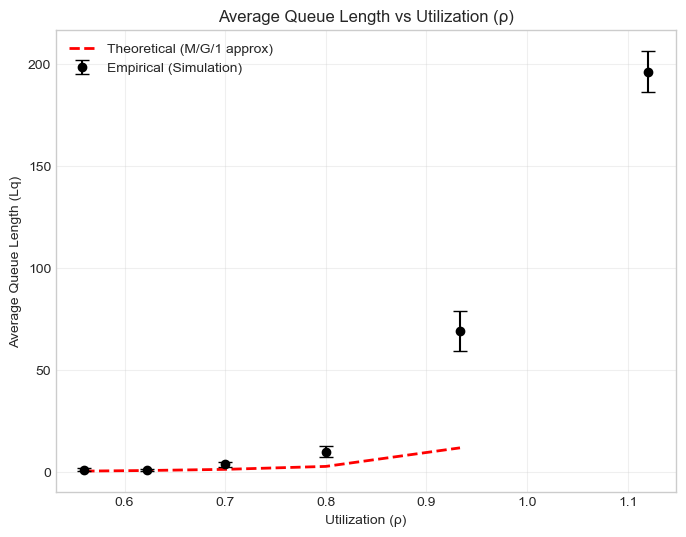

In [ ]:
# Utilization vs Queue Length (Theory Overlay)


def calculate_complex_theory(k, lam, mu1, sigma1, mu2, sigma2, prob):
    """
    Calculates P-K Formula for the Extended Model (treating it as a Mixture Distribution).
    """
    # Effective Service Time (E[S])
    # The senior officer adds time with probability 'prob'
    E_S = mu1 + (prob * mu2)
    
    # Variance of Effective Service (Var[S])
    # Formula for Variance of a Mixture Distribution:
    var1 = sigma1**2
    var2 = sigma2**2
    Var_S = var1 + (prob * var2) + (prob * (1 - prob) * (mu2**2))
    
    # Utilization (rho)
    rho = (lam / k) * E_S
    
    if rho >= 1: 
        return rho, float('inf') # Unstable
    
    # Pollaczek-Khinchine Formula
    # Lq = (lambda^2 * E[S^2]) / (2 * (1 - rho))  <-- Normalized for k queues
    
    # We need E[S^2] (Second Moment) = Var[S] + E[S]^2
    E_S2 = Var_S + E_S**2
    
    # Apply formula for M/G/1 (scaled by k)
    lam_k = lam / k
    Lq = (lam_k**2 * E_S2) / (2 * (1 - rho))
    
    return rho, Lq

def plot_utilization_vs_queue():
    '''
    Generates utilization vs queue plot
    '''
    lam = 10
    arrival_dist = sts.expon(scale=1/10)
    
    # Regular Service
    mu1, sig1 = 0.5, 1/6
    a1 = (0 - mu1) / sig1
    service_dist = sts.truncnorm(a1, np.inf, loc=mu1, scale=sig1)
    
    # Senior Service
    mu2, sig2 = 2.0, 2.0
    a2 = (0 - mu2) / sig2
    senior_dist = sts.truncnorm(a2, np.inf, loc=mu2, scale=sig2)
    
    check_prob = 0.03
    
    # Stations to test (High utilization -> Low utilization)
    station_counts = [5, 6, 7, 8, 9, 10]
    
    rhos = []
    emp_means = []
    emp_cis = []
    theory_vals = []
    
    for k in tqdm(station_counts):
        # 1. Run Simulation
        trial_results = []
        for _ in range(20): # 20 Replicates
            airport = run_extended_simulation(arrival_dist, service_dist, k, 1000, 
                                              senior_dist, check_prob)
            
            # Get Average Queue Length per station
            avg_q = sum(q.area_under_queue_curve / 1000 for q in airport.queues) / k
            trial_results.append(avg_q)
            
        # Store Empirical Stats
        emp_means.append(np.mean(trial_results))
        # 95% Confidence Interval
        emp_cis.append(1.96 * sts.sem(trial_results))
        
        # 2. Calculate Theory
        rho, th_Lq = calculate_complex_theory(k, lam, mu1, sig1, mu2, sig2, check_prob)
        rhos.append(rho)
        theory_vals.append(th_Lq)

    # plot
    # Sort data by Rho (Utilization) so the line connects correctly
    sorted_indices = np.argsort(rhos)
    rhos = np.array(rhos)[sorted_indices]
    emp_means = np.array(emp_means)[sorted_indices]
    emp_cis = np.array(emp_cis)[sorted_indices]
    theory_vals = np.array(theory_vals)[sorted_indices]

    plt.figure(figsize=(8, 6))
    
    # Plot Theory Line
    plt.plot(rhos, theory_vals, 'r--', label='Theoretical (M/G/1 approx)', lw=2)
    
    # Plot Empirical Dots with Error Bars
    plt.errorbar(rhos, emp_means, yerr=emp_cis, fmt='o', color='black', 
                 ecolor='black', capsize=5, label='Empirical (Simulation)')

    plt.title('Average Queue Length vs Utilization (ρ)')
    plt.xlabel('Utilization (ρ)')
    plt.ylabel('Average Queue Length (Lq)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_utilization_vs_queue()

STABILITY CHECK: Comparing k=9 (Risky) vs k=10 (Optimal)...


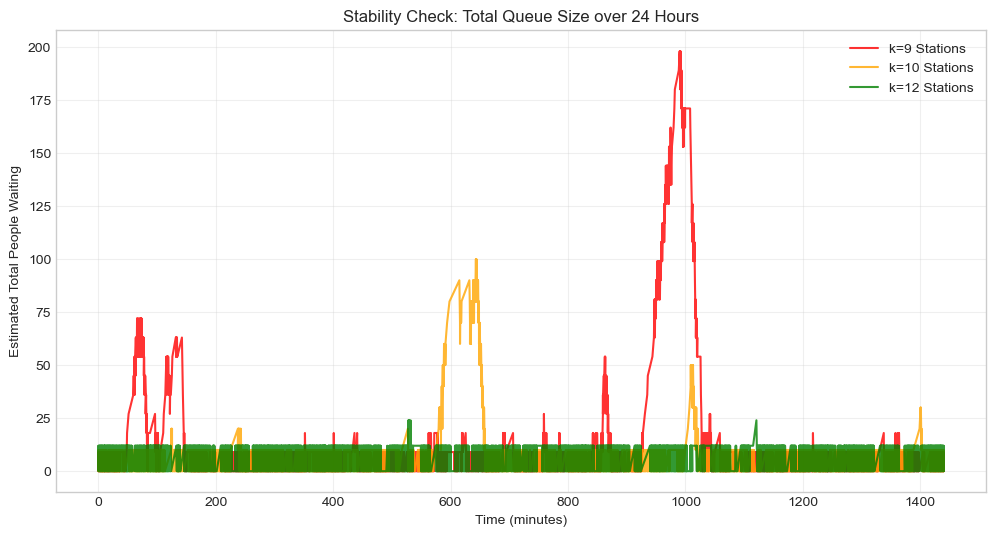

In [15]:
# STABILITY ANALYSIS (Trace Plots)

def plot_stability_check():
    print("STABILITY CHECK: Comparing k=9 (Risky) vs k=10 (Optimal)...")
    
    horizon = 1440 # 24 Hours
    arr = sts.expon(scale=1/10)
    mu1, sig1 = 0.5, 1/6
    srv = sts.truncnorm((0-mu1)/sig1, np.inf, loc=mu1, scale=sig1)
    mu2, sig2 = 2.0, 2.0
    sen = sts.truncnorm((0-mu2)/sig2, np.inf, loc=mu2, scale=sig2)
    
    scenarios = [9, 10, 12]
    colors = ['red', 'orange', 'green']
    
    plt.figure(figsize=(12, 6))
    
    for i, k in enumerate(scenarios):
        # Run one long simulation
        airport = run_extended_simulation(arr, srv, k, horizon, sen, check_prob=0.03)
        
        # Approximate Total Queue = Queue 0 Length * k
        q0_hist = airport.queues[0].queue_lenghts
        times = [x[0] for x in q0_hist]
        lengths = [x[1] * k for x in q0_hist]
        
        plt.plot(times, lengths, label=f'k={k} Stations', color=colors[i], alpha=0.8)
    
    plt.title('Stability Check: Total Queue Size over 24 Hours')
    plt.xlabel('Time (minutes)')
    plt.ylabel('Estimated Total People Waiting')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_stability_check()

📊 GENERATING WAIT TIME HISTOGRAMS (k=5, 6, 7)...


100%|██████████| 3/3 [09:00<00:00, 180.18s/it]


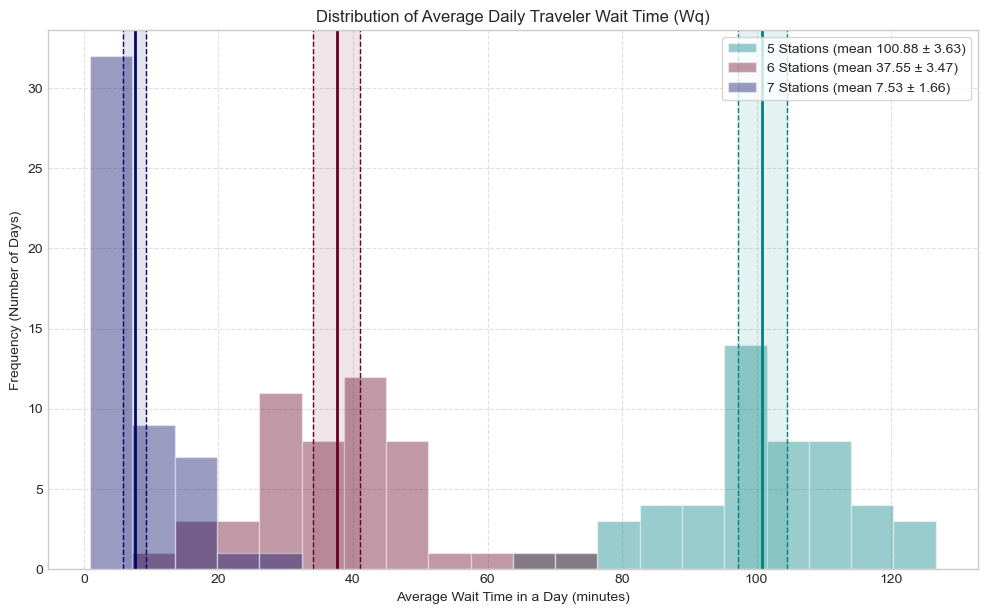

In [ ]:
# Wait Time Distribution Histogram

def plot_wait_time_histogram():
    print("WAIT TIME HISTOGRAMS (k=5, 6, 7)")
    
    # --- SETUP PARAMETERS ---
    # Using the same parameters as the final optimization
    arrival_dist = sts.expon(scale=1/10)
    
    # Regular Service
    mu1, sig1 = 0.5, 1/6
    a1 = (0 - mu1) / sig1
    service_dist = sts.truncnorm(a1, np.inf, loc=mu1, scale=sig1)
    
    # Senior Service
    mu2, sig2 = 2.0, 2.0
    a2 = (0 - mu2) / sig2
    senior_dist = sts.truncnorm(a2, np.inf, loc=mu2, scale=sig2)
    
    check_prob = 0.03
    
    # Stations to compare (The "Danger Zone")
    station_counts_to_plot = [5, 6, 7]
    
    # Store data in the format the plotting logic needs
    # Dictionary mapping k -> list of average wait times (one per trial)
    experiment_data = {}

    # --- 1. RUN SIMULATIONS TO COLLECT DATA ---
    for k in tqdm(station_counts_to_plot):
        trial_means = []
        for _ in range(50): # 50 Replicates per k
            airport = run_extended_simulation(arrival_dist, service_dist, k, 1000, 
                                              senior_dist, check_prob)
            
            # Collect all wait times in this specific day/trial
            all_waits = []
            for q in airport.queues:
                all_waits.extend(q.waiting_times)
            
            # We want the "Average Daily Wait Time" for this trial
            if all_waits:
                trial_means.append(np.mean(all_waits))
            else:
                trial_means.append(0)
        
        experiment_data[k] = trial_means

    # --- 2. PLOTTING LOGIC (Adapted from your example) ---
    color_map = {5:'#008080', 6:'#650021', 7:'#030764', 8:'#054907'}
    
    # Collect all data to build shared bins
    all_data_flat = []
    for k in station_counts_to_plot:
        all_data_flat.extend(experiment_data[k])
        
    if not all_data_flat:
        print("Error: No data to plot.")
        return

    # Create common bins so histograms are comparable
    num_bins = 20
    common_bins = np.linspace(min(all_data_flat), max(all_data_flat), num_bins + 1)

    plt.figure(figsize=(12, 7))
    ax = plt.gca()

    # Plot histograms + mean ± 95% CI overlays
    for n in station_counts_to_plot:
        # Convert list to array for math operations
        wait_time_data = np.array(experiment_data[n])
        color = color_map.get(n, 'gray')

        # Calculate Stats
        m = np.mean(wait_time_data)
        se = sts.sem(wait_time_data)
        ci = 1.96 * se
        lo, hi = m - ci, m + ci

        # Plot Histogram
        # We plot it twice (once for the bar, once for the label in legend)
        label_text = f'{n} Stations (mean {m:.2f} ± {ci:.2f})'
        
        ax.hist(wait_time_data, bins=common_bins, alpha=0.4, 
                label=label_text, edgecolor='white', color=color)

        # Vertical mean + CI lines
        ax.axvline(m, color=color, linewidth=2, linestyle='-')     # Solid line for Mean
        ax.axvline(lo, color=color, linestyle='--', linewidth=1)   # Dashed for CI Lower
        ax.axvline(hi, color=color, linestyle='--', linewidth=1)   # Dashed for CI Upper

        # Shaded CI band
        if hi > lo:
            ax.axvspan(lo, hi, color=color, alpha=0.1)

    plt.title('Distribution of Average Daily Traveler Wait Time (Wq)')
    plt.xlabel("Average Wait Time in a Day (minutes)")
    plt.ylabel("Frequency (Number of Days)")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Place legend outside to keep plot clean
    plt.legend(loc='upper right', frameon=True)
    plt.show()

plot_wait_time_histogram()

OPTIMIZATION (k=5 to 17)...


 46%|████▌     | 6/13 [13:47<17:25, 149.29s/it]


 OPTIMAL K: 10 (Wait: 0.85 min ± 0.33)


100%|██████████| 13/13 [27:49<00:00, 128.46s/it]


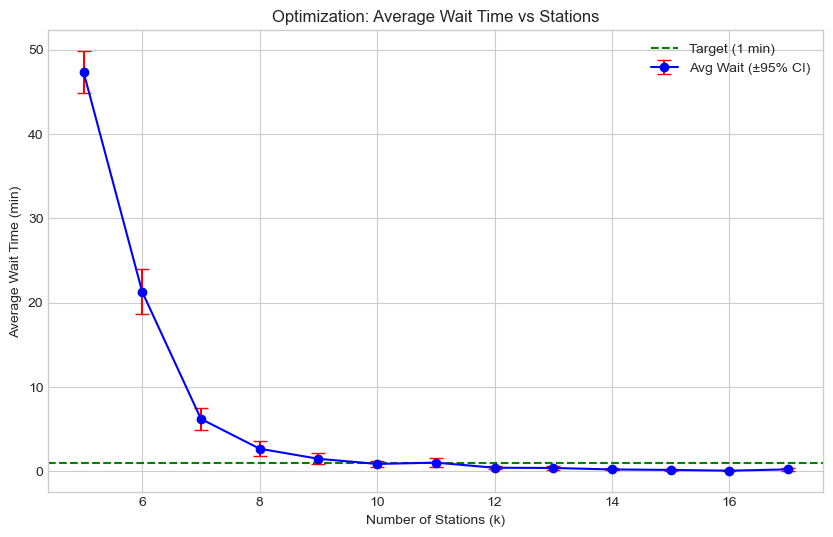

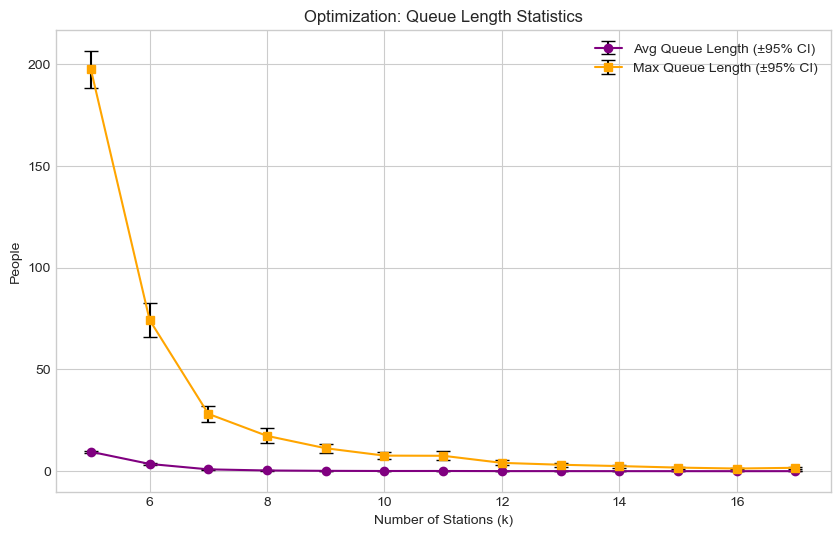

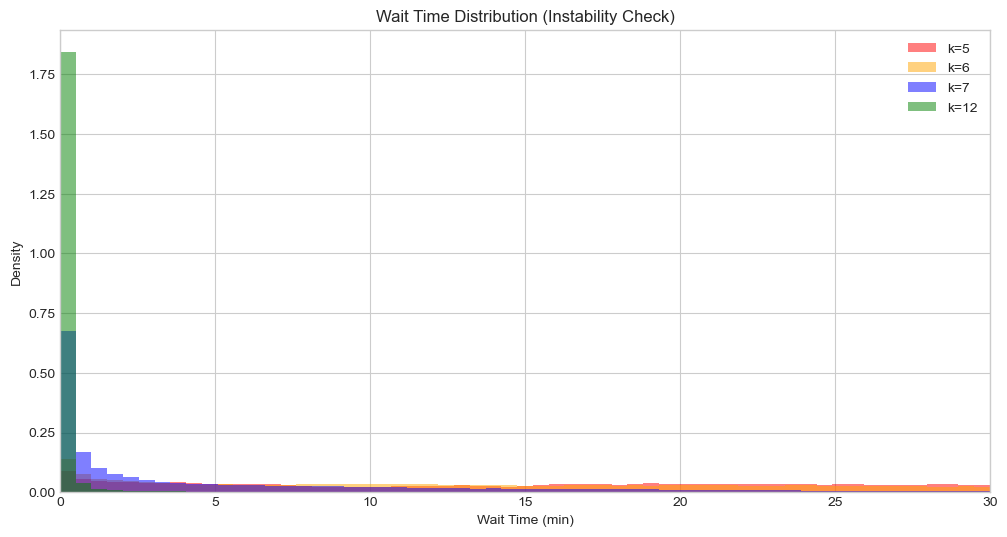

In [16]:
# FINAL OPTIMIZATION & PLOTTING

def optimize():
    print("OPTIMIZATION (k=5 to 17)...")
    
    #parameters
    arr = sts.expon(scale=1/10)
    
    mu1, sig1 = 0.5, 1/6
    srv = sts.truncnorm((0-mu1)/sig1, np.inf, loc=mu1, scale=sig1)
    
    mu2, sig2 = 2.0, 2.0
    sen = sts.truncnorm((0-mu2)/sig2, np.inf, loc=mu2, scale=sig2)
    
    k_vals = range(5, 18)
    
    # Storage for Plotting (Means and Confidence Intervals)
    waits_mean, waits_ci = [], []
    q_len_mean, q_len_ci = [], []
    max_q_mean, max_q_ci = [], []
    
    # Storage for Histogram
    hist_data = {5:[], 6:[], 7:[], 12:[]}
    
    optimal_k = None
    
    for k in tqdm(k_vals):
        trial_w, trial_l, trial_max = [], [], []
        
        # Run the simulation multiple times" (50 Independent Trials)
        for _ in range(50):
            # 500 to ensure equilibrium 
            airport = run_extended_simulation(arr, srv, k, 500, sen, check_prob=0.03)
            
            # Average traveler waiting time
            w_list = []
            for q in airport.queues: w_list.extend(q.waiting_times)
            trial_w.append(np.mean(w_list) if w_list else 0)
            
            # Average queue length during a day
            # (Calculated as Area Under Curve / Time, averaged per station)
            l = sum(q.area_under_queue_curve / 5000 for q in airport.queues) / k
            trial_l.append(l)

            # Maximum queue length during a day
            m = 0
            for q in airport.queues:
                if q.queue_lenghts:
                    # Max length observed in any queue during this trial
                    m = max(m, max(x[1] for x in q.queue_lenghts))
            trial_max.append(m)
            
            # Collect data for histogram
            if k in hist_data: hist_data[k].extend(w_list)

        # Compute expected value and 95% confidence interval
        def get_stats(data):
            m = np.mean(data)
            se = sts.sem(data)
            ci = 1.96 * se
            return m, ci

        wm, wci = get_stats(trial_w)
        lm, lci = get_stats(trial_l)
        mm, mci = get_stats(trial_max)
        
        waits_mean.append(wm); waits_ci.append(wci)
        q_len_mean.append(lm); q_len_ci.append(lci)
        max_q_mean.append(mm); max_q_ci.append(mci)
        
        if optimal_k is None and wm < 1.0:
            optimal_k = k
            print(f"\n OPTIMAL K: {k} (Wait: {wm:.2f} min ± {wci:.2f})")

    #PLOT 1: WAIT TIME (With CIs)
    plt.figure()
    plt.errorbar(k_vals, waits_mean, yerr=waits_ci, fmt='-o', color='blue', 
                 ecolor='red', capsize=5, label='Avg Wait (±95% CI)')
    plt.axhline(1.0, color='g', ls='--', label='Target (1 min)')
    
    
    plt.title('Optimization: Average Wait Time vs Stations')
    plt.xlabel('Number of Stations (k)')
    plt.ylabel('Average Wait Time (min)')
    plt.legend()
    plt.show()
    
    # PLOT 2: QUEUE LENGTHS (With CIs)
    #  "Provide empirical results... for Avg and Max Queue Length"
    plt.figure()
    plt.errorbar(k_vals, q_len_mean, yerr=q_len_ci, fmt='-o', color='purple', 
                 ecolor='black', capsize=5, label='Avg Queue Length (±95% CI)')
    plt.errorbar(k_vals, max_q_mean, yerr=max_q_ci, fmt='-s', color='orange', 
                 ecolor='black', capsize=5, label='Max Queue Length (±95% CI)')
    plt.title('Optimization: Queue Length Statistics')
    plt.xlabel('Number of Stations (k)')
    plt.ylabel('People')
    plt.legend()
    plt.show()
    
    #histograms plot
    plt.figure(figsize=(12,6))
    colors = ['r', 'orange', 'b', 'g']
    for i, k in enumerate([5, 6, 7, 12]):
        plt.hist(hist_data[k], bins=np.linspace(0,30,60), alpha=0.5, density=True, label=f'k={k}', color=colors[i])
    plt.title('Wait Time Distribution (Instability Check)')
    plt.xlabel('Wait Time (min)')
    plt.ylabel('Density')
    plt.xlim(0, 30)
    plt.legend()
    plt.show()

optimize()